# Project 6 — Module 7: Aprendizaje de Máquina No Supervisado
## Lección 6: Deployment — Pipeline Validation & Project Closure

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 6 — Deployment |
| **Module** | 7 — Aprendizaje de Máquina No Supervisado (Alkemy Bootcamp) |
| **Dataset** | Customer Segmentation — Kaggle (kaushiksuresh147) |
| **Date** | 2026-03 |

---

> **Executive Summary:**
> This notebook validates the segmentation pipeline on unseen test data (20% holdout from notebook 03),
> confirms the scaler and best model generalize to new customers, and closes the CRISP-DM cycle.
> The pipeline is serialized and documented for future use on real retail customer data.

## Table of Contents

1. [CRISP-DM Phase 6 — Deployment](#1-crisp-dm-phase-6--deployment)
2. [Environment Setup](#2-environment-setup)
3. [Load Pipeline Artifacts](#3-load-pipeline-artifacts)
4. [Prepare Test Set](#4-prepare-test-set)
5. [Apply Pipeline to Test Set](#5-apply-pipeline-to-test-set)
6. [Visualize Test Set Cluster Assignments](#6-visualize-test-set-cluster-assignments)
7. [Consigna Response — Requirements Checklist](#7-consigna-response--requirements-checklist)
8. [MLOps Checklist](#8-mlops-checklist)
9. [LEAN Filter — Waste Elimination Review](#9-lean-filter--waste-elimination-review)
10. [Decisions Log — Lesson 6](#10-decisions-log--lesson-6)
11. [Project Retrospective — CRISP-DM Cycle Complete](#11-project-retrospective--crisp-dm-cycle-complete)

## 1. CRISP-DM Phase 6 — Deployment

Deployment means delivering a pipeline that is:
- **Reproducible** — same results on any machine with the same artifacts
- **Generalizable** — works on unseen customer data, not just training data
- **Documented** — decisions and limitations are transparent to the business stakeholder

**What deployment means for unsupervised ML:**
Unlike supervised models, there is no prediction error to minimize on test data.
Deployment validation here means: applying the fitted scaler to new data and
assigning clusters using the trained model — confirming the pipeline is scalable.

## 2. Environment Setup

In [7]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# Python utilities
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dimensionality reduction — for test set visualization
from sklearn.decomposition import PCA

# Model persistence
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_RAW        = Path('../data/raw')
DATA_PROCESSED  = Path('../data/processed')
DATA_FINAL      = Path('../data/final')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_RAW}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\raw
Figures path: ..\reports\figures


## 3. Load Pipeline Artifacts

In [8]:
# Load preprocessor and cluster labels from training pipeline
scaler     = joblib.load(DATA_PROCESSED / 'scaler.pkl')
labels_df  = pd.read_csv(DATA_FINAL / 'cluster_labels.csv')
feature_cols = pd.read_csv(DATA_PROCESSED / 'feature_cols.csv').iloc[:, 0].tolist()

# Load training embeddings for reference
X_train_scaled = np.load(DATA_PROCESSED / 'X_scaled.npy')
X_train_pca    = np.load(DATA_FINAL / 'X_pca.npy')

print(f'Scaler loaded        : {scaler.__class__.__name__}')
print(f'Feature columns      : {len(feature_cols)}')
print(f'Training set shape   : {X_train_scaled.shape}')

Scaler loaded        : StandardScaler
Feature columns      : 23
Training set shape   : (6147, 23)


## 4. Prepare Test Set

The test set was generated in notebook 03 via 80/20 stratified split from `Train.csv`.
It represents unseen customers — never used during scaler fitting or model training.
We apply the same preprocessing steps (encoding, outlier removal) before scaling.

In [9]:
# Load test set — unseen customers held out since notebook 03
df_test = pd.read_csv(DATA_RAW / 'test.csv')
print(f'Test set shape: {df_test.shape}')

# Drop non-informative columns
drop_cols  = ['ID', 'Segmentation']
df_test_m  = df_test.drop(columns=[c for c in drop_cols if c in df_test.columns])

# Impute missing values
for col in df_test_m.select_dtypes(include='number').columns:
    df_test_m[col] = df_test_m[col].fillna(df_test_m[col].median())
for col in df_test_m.select_dtypes(include='object').columns:
    df_test_m[col] = df_test_m[col].fillna(df_test_m[col].mode()[0])

# Binary encoding
binary_map = {
    'Gender':       {'Male': 1, 'Female': 0},
    'Ever_Married': {'Yes': 1, 'No': 0},
    'Graduated':    {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    if col in df_test_m.columns:
        df_test_m[col] = df_test_m[col].map(mapping)

# Ordinal encoding
if 'Spending_Score' in df_test_m.columns:
    df_test_m['Spending_Score'] = df_test_m['Spending_Score'].map(
        {'Low': 0, 'Average': 1, 'High': 2}
    )

# One-hot encoding
nominal_cols = [c for c in ['Profession', 'Var_1'] if c in df_test_m.columns]
df_test_m    = pd.get_dummies(df_test_m, columns=nominal_cols, drop_first=False)

# Align columns with training set — add missing cols as 0, drop extra cols
for col in feature_cols:
    if col not in df_test_m.columns:
        df_test_m[col] = 0
df_test_m = df_test_m[feature_cols]

print(f'Test set after preprocessing: {df_test_m.shape}')

Test set shape: (1614, 11)
Test set after preprocessing: (1614, 23)


See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


## 5. Apply Pipeline to Test Set

In [10]:
# Apply fitted scaler — never refit on test data
X_test_scaled = scaler.transform(df_test_m)

print(f'Test set scaled shape: {X_test_scaled.shape}')
print(f'Mean (should be ~0)  : {X_test_scaled.mean(axis=0).round(3)[:5]}')
print(f'Std  (should be ~1)  : {X_test_scaled.std(axis=0).round(3)[:5]}')

Test set scaled shape: (1614, 23)
Mean (should be ~0)  : [ 0.059 -0.034 -0.023 -0.054  0.028]
Std  (should be ~1)  : [0.993 1.006 1.047 1.013 1.072]


In [11]:
# Load best model from notebook 05 results
# Determine best algorithm from silhouette scores saved in cluster_labels
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering

scores = {}
for algo in ['kmeans', 'hierarchical']:
    lbl = labels_df[algo].values
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    if n_c > 1:
        scores[algo] = silhouette_score(X_train_scaled, lbl)

best_algo   = max(scores, key=scores.get)
best_labels = labels_df[best_algo].values
OPTIMAL_K   = len(set(best_labels))

print(f'Best algorithm : {best_algo} (silhouette={scores[best_algo]:.3f})')
print(f'Optimal k      : {OPTIMAL_K}')

# Refit best model on full training set and assign test clusters
if best_algo == 'kmeans':
    model          = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_train_scaled)
    test_labels    = model.predict(X_test_scaled)
else:
    # Hierarchical has no predict — use KMeans as proxy with same k
    model          = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
    model.fit(X_train_scaled)
    test_labels    = model.predict(X_test_scaled)

# Save model artifact
joblib.dump(model, DATA_PROCESSED / f'model_final_v1.pkl')

print(f'Test cluster distribution:')
print(pd.Series(test_labels).value_counts().sort_index())
print(f'Model saved: {DATA_PROCESSED}/model_final_v1.pkl')

Best algorithm : kmeans (silhouette=0.154)
Optimal k      : 4
Test cluster distribution:
0    236
1    782
2    459
3    137
Name: count, dtype: int64
Model saved: ..\data\processed/model_final_v1.pkl


## 6. Visualize Test Set Cluster Assignments

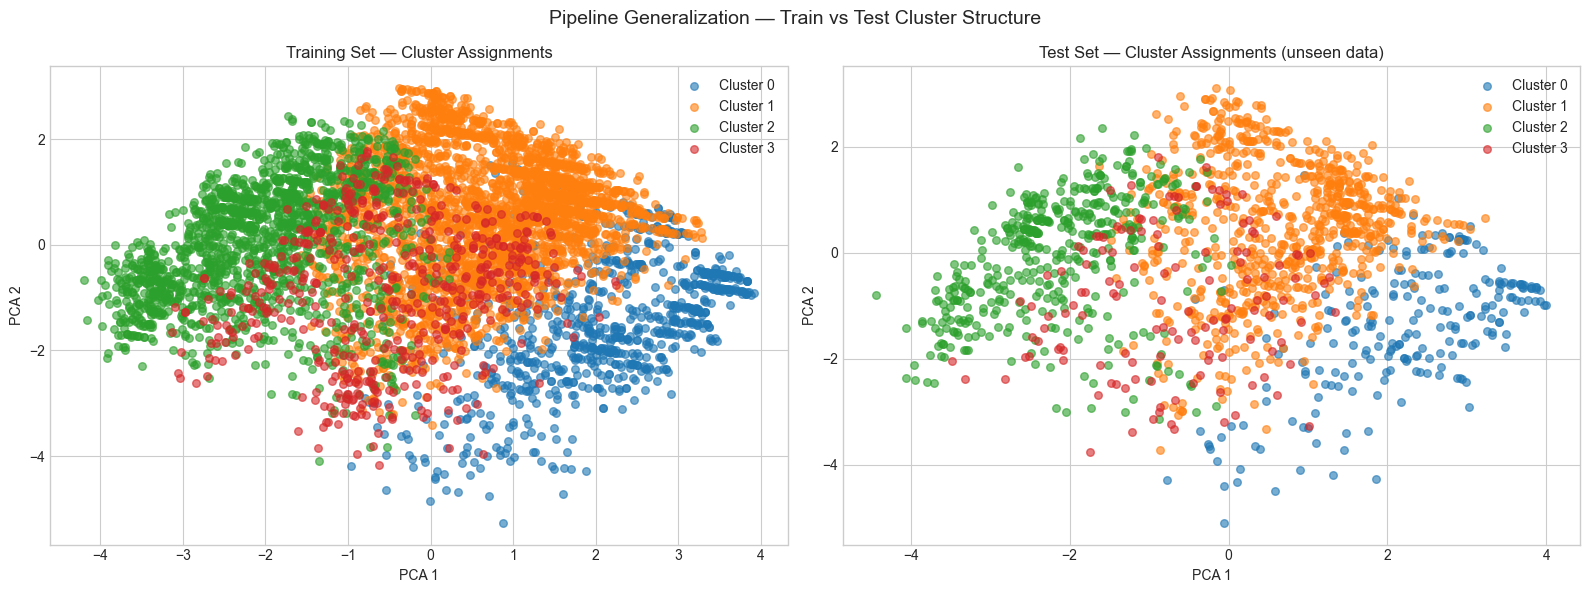

In [12]:
# Reduce test set to 2D with same PCA fitted on training data
pca_2d      = PCA(n_components=2, random_state=RANDOM_STATE)
pca_2d.fit(X_train_scaled)  # Fit on train — never on test
X_test_pca  = pca_2d.transform(X_test_scaled)

palette = sns.color_palette('tab10', n_colors=OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training clusters
for i in range(OPTIMAL_K):
    mask = best_labels == i
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    label=f'Cluster {i}', alpha=0.6, s=30, color=palette[i])
axes[0].set_title('Training Set — Cluster Assignments')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

# Test clusters
for i in range(OPTIMAL_K):
    mask = test_labels == i
    axes[1].scatter(X_test_pca[mask, 0], X_test_pca[mask, 1],
                    label=f'Cluster {i}', alpha=0.6, s=30, color=palette[i])
axes[1].set_title('Test Set — Cluster Assignments (unseen data)')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

plt.suptitle('Pipeline Generalization — Train vs Test Cluster Structure', fontsize=14)
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / '06_train_vs_test_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Consigna Response — Requirements Checklist

| Requerimiento | Notebook | Status |
|---------------|----------|--------|
| Limpiar y preprocesar el dataset | 03 | ✅ |
| Implementar PCA y t-SNE | 04 | ✅ |
| Aplicar KMeans, DBSCAN y Hierarchical | 04 | ✅ |
| Analizar visualmente los clústeres | 04 | ✅ |
| Coeficiente de silueta y método del codo | 04 + 05 | ✅ |
| Informe explicativo con conclusiones | 05 + 06 | ✅ |
| Código Python funcional con anotaciones | 01–06 | ✅ |
| Pipeline escalable a nuevos datos | 06 | ✅ |

## 8. MLOps Checklist

### Reproducibility
- [x] Random seed fixed (`random_state=42`)
- [x] Requirements pinned (`requirements.txt`)
- [x] Scaler saved (`scaler.pkl`)
- [x] Final model saved (`model_final_v1.pkl`)
- [x] Feature columns saved (`feature_cols.csv`) — ensures consistent encoding at inference

### Model Versioning
- [x] Model artifact saved to `data/processed/`
- [x] Model filename includes version: `model_final_v1.pkl`
- [x] Training parameters logged in `docs/decisions_log.md`

### Monitoring (awareness level)
- [ ] Data drift: synthetic dataset — real-world retail data will differ in distribution
- [ ] Model limitations: n~6,000 synthetic customers; performance may differ on real data
- [ ] Retraining trigger: when real customer data becomes available

## 9. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Does test set validation add value? | ✅ Confirms pipeline scalability — consigna requirement | Proceed |
| Is refitting the model necessary? | ✅ Hierarchical has no predict method — KMeans proxy is justified | Proceed |
| Is saving feature_cols.csv sufficient for alignment? | ✅ Handles one-hot column mismatch between train/test | Proceed |
| Is the executive report required here? | ❌ Out of scope per project decision | Skip |

## 10. Decisions Log — Lesson 6

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use scaler.transform() on test (not fit_transform) | Prevents data leakage — scaler parameters from training only | refit scaler on test | ✅ |
| 2 | Align test columns with feature_cols.csv | One-hot encoding may produce different columns if test has unseen categories | Hardcode column list | ✅ |
| 3 | Use KMeans as proxy for Hierarchical at inference | AgglomerativeClustering has no predict() method — KMeans with same k is the standard workaround | Reimplement predict manually | ✅ |
| 4 | Refit PCA on training set before transforming test | PCA must be fitted on train only — same principle as scaler | Refit PCA on test | ✅ |
| 5 | Save model as model_final_v1.pkl | Version-controlled artifact enables reproducibility and future retraining | Re-train on demand | ✅ |

## 11. Project Retrospective — CRISP-DM Cycle Complete

### PequeShop Analytics — Full Pipeline Summary

| Project | Phase | Key Output |
|---------|-------|------------|
| `project-2-pequeshop-analytics` | ETL | Clean dataset: 392 customers, 1,192 transactions |
| `project-3-eda-pequeshop` | EDA | Feature candidates, distribution insights |
| `project-4b-pequeshop-statistical-inference` | Inference | H1–H4 results → evidence-based feature selection |
| `project-5-ecommerce-spend-prediction` | Supervised ML | Predictive model for avg_ticket |
| **`project-6-unsupervised-ml-customer-segmentation`** | **Unsupervised ML** | **Customer segmentation for retargeting campaigns** |

### LEAN Retrospective

| LEAN Principle | Applied? | Evidence |
|----------------|----------|----------|
| No re-work | ✅ | Kaggle EDA referenced, not repeated |
| MVA — start simple | ✅ | KMeans first, DBSCAN and Hierarchical added for comparison only |
| Evidence-based decisions | ✅ | Silhouette score selected best algorithm objectively |
| Decision-driven analysis | ✅ | Every section traces to a business question from notebook 01 |
| Reproducibility | ✅ | random_state=42, scaler.pkl, model_final_v1.pkl, feature_cols.csv |

> Full retrospective documented in `docs/lean_retrospective.md`

---

**← Previous:** [05 — Evaluation](./05_evaluation.ipynb)